# Train Data

In [3]:
# Make necessary imports 

import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from collections import Counter
import numpy as np
from scipy.stats import randint

# Data

In [4]:

# Path to your CSV file
file_path = r"GUIDE_Train[1].csv"

# Target row count per class
target_rows_per_class = 500_000

# Initialize dictionaries to store sampled data for each class
samples_per_class = {'BenignPositive': [], 'TruePositive': [], 'FalsePositive': []}

# Define chunk size to avoid memory overload
chunk_size = 100_000

# Read the CSV file in chunks
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # For each class, sample rows if the target has not been reached
    for class_value in samples_per_class.keys():
        # Filter rows of the current class
        class_rows = chunk[chunk['IncidentGrade'] == class_value]

        
        # Calculate how many more rows are needed for this class
        remaining_rows = target_rows_per_class - sum(len(df) for df in samples_per_class[class_value])
        
        # If more rows are needed, sample accordingly
        if remaining_rows > 0:
            samples_per_class[class_value].append(class_rows.sample(n=min(remaining_rows, len(class_rows))))

    # Stop reading further chunks if we’ve collected enough rows for each class
    if all(sum(len(df) for df in samples) >= target_rows_per_class for samples in samples_per_class.values()):
        break

# Concatenate samples to create the final balanced dataset
train_data = pd.concat([pd.concat(samples) for samples in samples_per_class.values()])


C:\Users\dhars\AppData\Local\Temp\ipykernel_17292\859912489.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_17292\859912489.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_17292\859912489.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_17292\859912489.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_17292\859912489.py:14: DtypeWarning: Col

In [19]:
import pandas as pd
train_data = pd.read_csv("train_data.csv")
train_data


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,876173330448,19,663,2220,2024-05-27T07:27:56.000Z,23,16,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1,163208759389,1526,70998,632297,2024-06-04T21:50:28.000Z,85,63,Discovery,T1007;T1016;T1018;T1049;T1087;T1135,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
2,833223656786,44,8833,9752,2024-06-13T21:12:03.000Z,50,36,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
3,1030792152862,771,49554,50586,2024-06-09T02:08:55.000Z,1,1,InitialAccess,T1566.002,BenignPositive,...,NaN,NaN,5,66,Inbound,NaN,Malicious,242,1445,10630
4,1288490190139,161,31798,222463,2024-06-05T14:29:03.000Z,11,9,InitialAccess,T1566,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,884763263898,18,3561,56438,2024-06-10T05:07:16.000Z,129,2371,Exfiltration,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1499996,180388631256,4,287,457,2024-05-29T05:43:08.000Z,8,7,InitialAccess,T1133,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1499997,1666447311459,93,9,0,2024-06-12T01:27:49.000Z,27,18,Discovery,T1087;T1087.002,FalsePositive,...,NaN,Suspicious,5,66,NaN,NaN,NaN,242,1445,10630
1499998,1443109015998,105,44858,119566,2024-06-11T17:21:59.000Z,6,5,InitialAccess,T1566,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630


In [20]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 45 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Id                  1500000 non-null  int64  
 1   OrgId               1500000 non-null  int64  
 2   IncidentId          1500000 non-null  int64  
 3   AlertId             1500000 non-null  int64  
 4   Timestamp           1500000 non-null  object 
 5   DetectorId          1500000 non-null  int64  
 6   AlertTitle          1500000 non-null  int64  
 7   Category            1500000 non-null  object 
 8   MitreTechniques     662484 non-null   object 
 9   IncidentGrade       1500000 non-null  object 
 10  ActionGrouped       817 non-null      object 
 11  ActionGranular      817 non-null      object 
 12  EntityType          1500000 non-null  object 
 13  EvidenceRole        1500000 non-null  object 
 14  DeviceId            1500000 non-null  int64  
 15  Sha256         

# Find Null

In [21]:
train_data.isna().sum() 


Id                          0
OrgId                       0
IncidentId                  0
AlertId                     0
Timestamp                   0
DetectorId                  0
AlertTitle                  0
Category                    0
MitreTechniques        837516
IncidentGrade               0
ActionGrouped         1499183
ActionGranular        1499183
EntityType                  0
EvidenceRole                0
DeviceId                    0
Sha256                      0
IpAddress                   0
Url                         0
AccountSid                  0
AccountUpn                  0
AccountObjectId             0
AccountName                 0
DeviceName                  0
NetworkMessageId            0
EmailClusterId        1485114
RegistryKey                 0
RegistryValueName           0
RegistryValueData           0
ApplicationId               0
ApplicationName             0
OAuthApplicationId          0
ThreatFamily          1489047
FileName                    0
FolderPath

# # drop duplicate rows

In [22]:
print(train_data.duplicated().sum())
train_data.drop_duplicates(inplace=True)
print(train_data.duplicated().sum())


797
0


# Drop columns due to more null

In [23]:
df=df.drop(columns=['MitreTechniques', 'ActionGrouped', 'ActionGranular', 
                      'EmailClusterId', 'ThreatFamily', 'ResourceType', 
                      'Roles', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict'])

In [24]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1499203 entries, 0 to 1499999
Data columns (total 35 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   Id                  1499203 non-null  int64 
 1   OrgId               1499203 non-null  int64 
 2   IncidentId          1499203 non-null  int64 
 3   AlertId             1499203 non-null  int64 
 4   Timestamp           1499203 non-null  object
 5   DetectorId          1499203 non-null  int64 
 6   AlertTitle          1499203 non-null  int64 
 7   Category            1499203 non-null  object
 8   IncidentGrade       1499203 non-null  object
 9   EntityType          1499203 non-null  object
 10  EvidenceRole        1499203 non-null  object
 11  DeviceId            1499203 non-null  int64 
 12  Sha256              1499203 non-null  int64 
 13  IpAddress           1499203 non-null  int64 
 14  Url                 1499203 non-null  int64 
 15  AccountSid          1499203 non-null 

# Check Null value

In [25]:
train_data.isna().sum()


Id                    0
OrgId                 0
IncidentId            0
AlertId               0
Timestamp             0
DetectorId            0
AlertTitle            0
Category              0
IncidentGrade         0
EntityType            0
EvidenceRole          0
DeviceId              0
Sha256                0
IpAddress             0
Url                   0
AccountSid            0
AccountUpn            0
AccountObjectId       0
AccountName           0
DeviceName            0
NetworkMessageId      0
RegistryKey           0
RegistryValueName     0
RegistryValueData     0
ApplicationId         0
ApplicationName       0
OAuthApplicationId    0
FileName              0
FolderPath            0
ResourceIdName        0
OSFamily              0
OSVersion             0
CountryCode           0
State                 0
City                  0
dtype: int64

# Feature engineering

In [26]:
# Converting Timestamp column into Day, Month and Hour

train_data['Timestamp'] = pd.to_datetime(train_data['Timestamp'])
train_data['Day']=train_data['Timestamp'].dt.day
train_data['Month']=train_data['Timestamp'].dt.month
train_data['Hour']=train_data['Timestamp'].dt.hour
train_data.drop('Timestamp',axis=1,inplace=True)

C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\2864121014.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Timestamp'] = pd.to_datetime(train_data['Timestamp'])
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\2864121014.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Day']=train_data['Timestamp'].dt.day
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\2864121014.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

## Data visualization

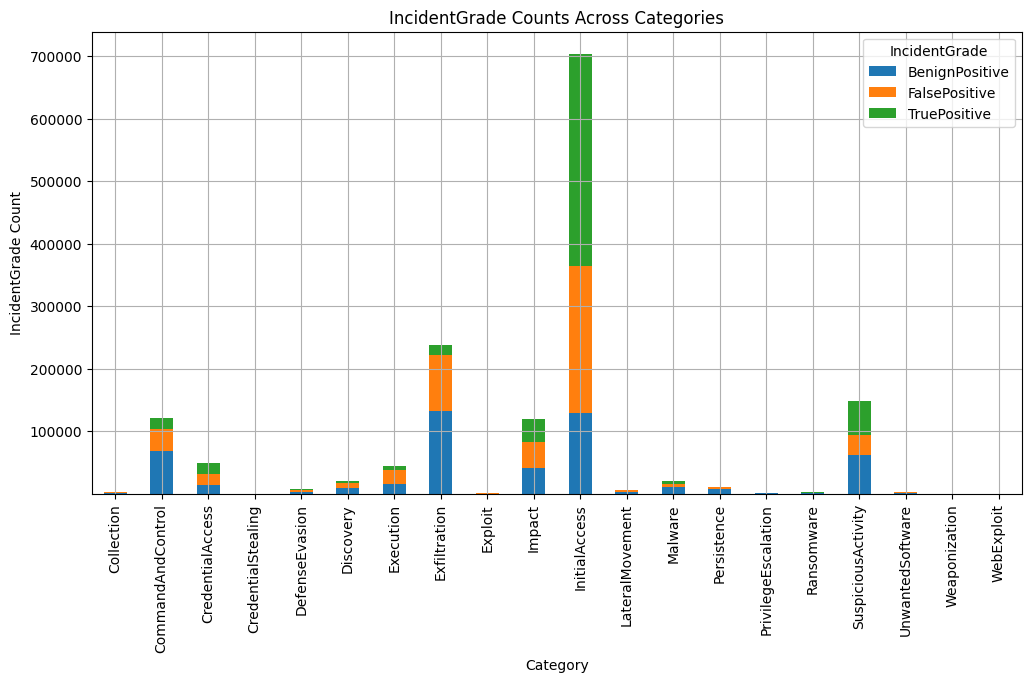

In [27]:
# Bar plot of IncidentGrade count by Category
import matplotlib.pyplot as plt

df=train_data.groupby(["Category","IncidentGrade"]).size().unstack()

# Plot
df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Category')
plt.ylabel('IncidentGrade Count')
plt.title('IncidentGrade Counts Across Categories')
plt.legend(title='IncidentGrade')
plt.grid(True)
plt.show()

# Heap Map

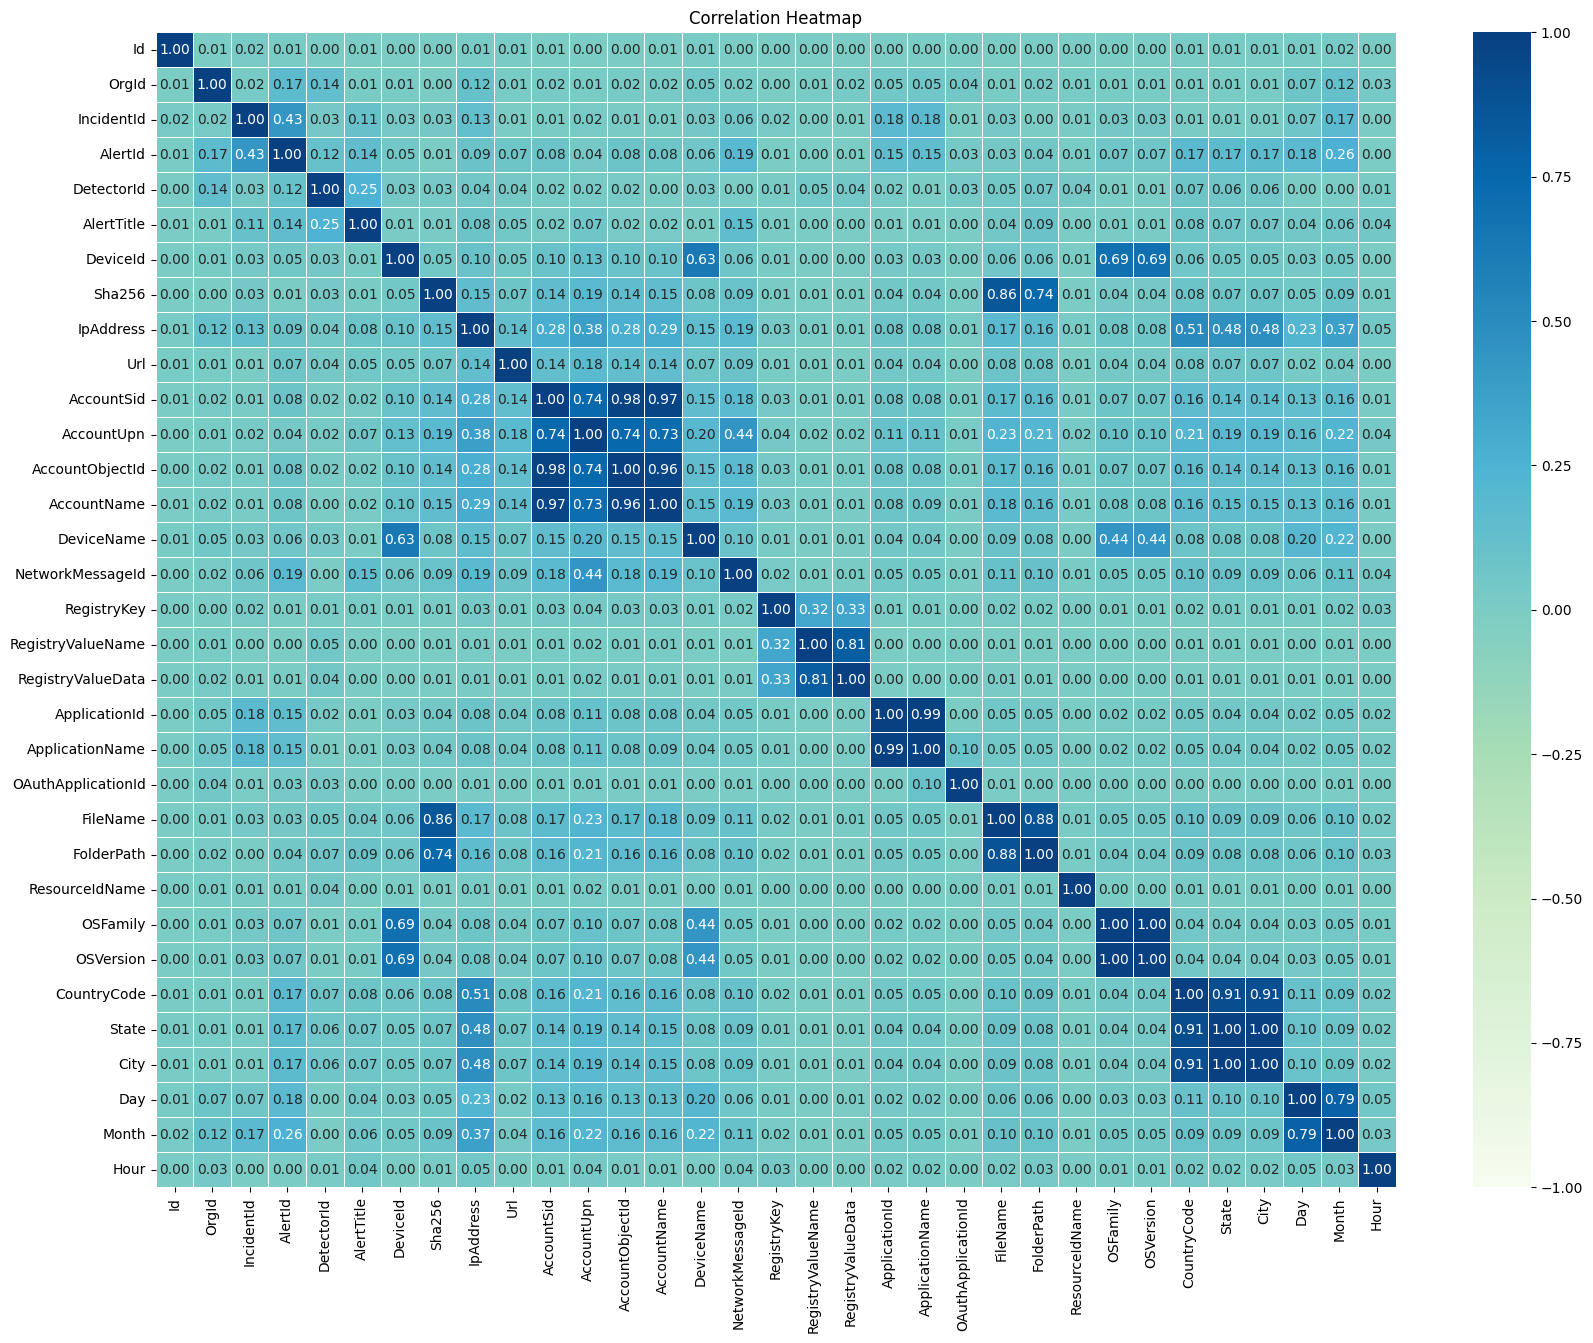

In [28]:
# Correlation heatmap for all numerical columns in our dataset
import matplotlib.pyplot as plt  # import matplotlib
import seaborn as sns 
numerical_df = train_data.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numerical_df.corr().abs()

# Plot the heatmap
plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True, cmap='GnBu', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Outlier

In [29]:
# Create a copy of df to clean
df_clean = train_data.copy()

for col in numerical_df:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only rows within the bounds
    train_data = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Original shape: {train_data.shape}")
print(f"Cleaned shape: {df_clean.shape}")


Original shape: (1499203, 37)
Cleaned shape: (1499203, 37)


In [30]:
train_data

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,...,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City,Day,Month,Hour
0,876173330448,19,663,2220,23,16,CommandAndControl,BenignPositive,Url,Related,...,117668,3586,5,66,242,1445,10630,27,5,7
1,163208759389,1526,70998,632297,85,63,Discovery,BenignPositive,Process,Related,...,3,3586,5,66,242,1445,10630,4,6,21
2,833223656786,44,8833,9752,50,36,Exfiltration,BenignPositive,MailMessage,Impacted,...,117668,3586,5,66,242,1445,10630,13,6,21
3,1030792152862,771,49554,50586,1,1,InitialAccess,BenignPositive,MailMessage,Related,...,117668,3586,5,66,242,1445,10630,9,6,2
4,1288490190139,161,31798,222463,11,9,InitialAccess,BenignPositive,User,Impacted,...,117668,3586,5,66,242,1445,10630,5,6,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,884763263898,18,3561,56438,129,2371,Exfiltration,FalsePositive,File,Impacted,...,261,3586,5,66,242,1445,10630,10,6,5
1499996,180388631256,4,287,457,8,7,InitialAccess,FalsePositive,Machine,Impacted,...,117668,3586,5,66,242,1445,10630,29,5,5
1499997,1666447311459,93,9,0,27,18,Discovery,FalsePositive,User,Impacted,...,117668,3586,5,66,242,1445,10630,12,6,1
1499998,1443109015998,105,44858,119566,6,5,InitialAccess,FalsePositive,MailCluster,Related,...,117668,3586,5,66,242,1445,10630,11,6,17


In [31]:
numerical_df1 = train_data.select_dtypes(include=['number'])

In [32]:
import numpy as np

# Setting a correlation threshold
threshold = 0.8

# Find pairs of columns with high correlations
high_corr_var = np.where(corr_matrix > threshold)
high_corr_pairs = [(numerical_df1.columns[x], numerical_df1.columns[y]) 
                    for x, y in zip(*high_corr_var) 
                    if x != y and x < y]
high_corr_pairs

[('Sha256', 'FileName'),
 ('AccountSid', 'AccountObjectId'),
 ('AccountSid', 'AccountName'),
 ('AccountObjectId', 'AccountName'),
 ('RegistryValueName', 'RegistryValueData'),
 ('ApplicationId', 'ApplicationName'),
 ('FileName', 'FolderPath'),
 ('OSFamily', 'OSVersion'),
 ('CountryCode', 'State'),
 ('CountryCode', 'City'),
 ('State', 'City')]

In [33]:
# Create a list of columns to remove
import numpy as np

columns_to_remove = set()
for col1, col2 in high_corr_pairs:
        columns_to_remove.add(col2)  # Default to adding the second column in each pair

# Convert to list
columns_to_remove = list(columns_to_remove)

#print(columns_to_remove)
# Drop the redundant columns
df_cleaned_corr = df_clean.drop(columns=columns_to_remove)

# Verify the cleaned DataFrame
print("Columns removed:", columns_to_remove)
df_cleaned_corr.head()

Columns removed: ['RegistryValueData', 'FileName', 'FolderPath', 'AccountObjectId', 'AccountName', 'City', 'OSVersion', 'ApplicationName', 'State']


,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,...,RegistryKey,RegistryValueName,ApplicationId,OAuthApplicationId,ResourceIdName,OSFamily,CountryCode,Day,Month,Hour
0,876173330448,19,663,2220,23,16,CommandAndControl,BenignPositive,Url,Related,...,1631,635,2251,881,3586,5,242,27,5,7
1,163208759389,1526,70998,632297,85,63,Discovery,BenignPositive,Process,Related,...,1631,635,2251,881,3586,5,242,4,6,21
2,833223656786,44,8833,9752,50,36,Exfiltration,BenignPositive,MailMessage,Impacted,...,1631,635,2251,881,3586,5,242,13,6,21
3,1030792152862,771,49554,50586,1,1,InitialAccess,BenignPositive,MailMessage,Related,...,1631,635,2251,881,3586,5,242,9,6,2
4,1288490190139,161,31798,222463,11,9,InitialAccess,BenignPositive,User,Impacted,...,1631,635,2251,881,3586,5,242,5,6,14


In [34]:
df_cleaned_corr

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,...,RegistryKey,RegistryValueName,ApplicationId,OAuthApplicationId,ResourceIdName,OSFamily,CountryCode,Day,Month,Hour
0,876173330448,19,663,2220,23,16,CommandAndControl,BenignPositive,Url,Related,...,1631,635,2251,881,3586,5,242,27,5,7
1,163208759389,1526,70998,632297,85,63,Discovery,BenignPositive,Process,Related,...,1631,635,2251,881,3586,5,242,4,6,21
2,833223656786,44,8833,9752,50,36,Exfiltration,BenignPositive,MailMessage,Impacted,...,1631,635,2251,881,3586,5,242,13,6,21
3,1030792152862,771,49554,50586,1,1,InitialAccess,BenignPositive,MailMessage,Related,...,1631,635,2251,881,3586,5,242,9,6,2
4,1288490190139,161,31798,222463,11,9,InitialAccess,BenignPositive,User,Impacted,...,1631,635,2251,881,3586,5,242,5,6,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,884763263898,18,3561,56438,129,2371,Exfiltration,FalsePositive,File,Impacted,...,1631,635,2251,881,3586,5,242,10,6,5
1499996,180388631256,4,287,457,8,7,InitialAccess,FalsePositive,Machine,Impacted,...,1631,635,2251,881,3586,5,242,29,5,5
1499997,1666447311459,93,9,0,27,18,Discovery,FalsePositive,User,Impacted,...,1631,635,2251,881,3586,5,242,12,6,1
1499998,1443109015998,105,44858,119566,6,5,InitialAccess,FalsePositive,MailCluster,Related,...,1631,635,2251,881,3586,5,242,11,6,17


# Label Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cat_cols = ['Category', 'IncidentGrade', 'EntityType','EvidenceRole']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each column
for col in cat_cols:
    df_cleaned_corr[col] = le.fit_transform(df_cleaned_corr[col])

# Check first 5 rows
print(df_cleaned_corr[cat_cols].head())


   Category  IncidentGrade  EntityType  EvidenceRole
0         1              0          26             1
1         5              0          22             1
2         7              0          16             0
3        10              0          16             1
4        10              0          27             0


In [37]:
df_cleaned_corr.to_csv('Train.csv', index=False)

# Test Data

In [38]:

# Path to your CSV file
file_path = r"GUIDE_Train[1].csv"

# Target row count per class
target_rows_per_class = 500_000

# Initialize dictionaries to store sampled data for each class
samples_per_class = {'BenignPositive': [], 'TruePositive': [], 'FalsePositive': []}

# Define chunk size to avoid memory overload
chunk_size = 100_000

# Read the CSV file in chunks
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # For each class, sample rows if the target has not been reached
    for class_value in samples_per_class.keys():
        # Filter rows of the current class
        class_rows = chunk[chunk['IncidentGrade'] == class_value]

        
        # Calculate how many more rows are needed for this class
        remaining_rows = target_rows_per_class - sum(len(df) for df in samples_per_class[class_value])
        
        # If more rows are needed, sample accordingly
        if remaining_rows > 0:
            samples_per_class[class_value].append(class_rows.sample(n=min(remaining_rows, len(class_rows))))

    # Stop reading further chunks if we’ve collected enough rows for each class
    if all(sum(len(df) for df in samples) >= target_rows_per_class for samples in samples_per_class.values()):
        break

# Concatenate samples to create the final balanced dataset
test = pd.concat([pd.concat(samples) for samples in samples_per_class.values()])


C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\3667277325.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\3667277325.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\3667277325.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\3667277325.py:14: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):
C:\Users\dhars\AppData\Local\Temp\ipykernel_21580\3667277325.py:14: DtypeWarning

In [39]:
test.to_csv('test.csv', index=False)

In [62]:
import pandas as pd
test = pd.read_csv("test.csv")
test


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,197568495903,181,69872,670359,2024-06-08T20:10:41.000Z,189,88,CredentialAccess,T1110,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1,1082331759668,125,775,57540,2024-06-12T08:02:20.000Z,322,19962,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
2,1065151892732,2,14200,19507,2024-06-09T05:48:12.000Z,15,13,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
3,979252544595,16,43626,26727,2024-06-03T12:46:58.000Z,24,11820,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
4,798863921511,380,147297,955627,2024-06-10T14:49:18.000Z,0,0,InitialAccess,T1078;T1078.004,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,1382979471298,122,1263,287317,2024-06-06T13:14:16.000Z,2,2,CommandAndControl,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
1499996,128849020623,45,49336,27157,2024-06-11T14:32:55.000Z,6,5,InitialAccess,T1566,FalsePositive,...,NaN,NaN,5,66,Inbound,NaN,NaN,242,1445,10630
1499997,807453852080,160,261806,197885,2024-06-08T23:44:28.000Z,3,4,SuspiciousActivity,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
1499998,644245096545,271,257,14559,2024-06-11T07:26:17.000Z,144,7235,Exfiltration,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


In [63]:
test.isna().sum() 
    

Id                          0
OrgId                       0
IncidentId                  0
AlertId                     0
Timestamp                   0
DetectorId                  0
AlertTitle                  0
Category                    0
MitreTechniques        837533
IncidentGrade               0
ActionGrouped         1499187
ActionGranular        1499187
EntityType                  0
EvidenceRole                0
DeviceId                    0
Sha256                      0
IpAddress                   0
Url                         0
AccountSid                  0
AccountUpn                  0
AccountObjectId             0
AccountName                 0
DeviceName                  0
NetworkMessageId            0
EmailClusterId        1485130
RegistryKey                 0
RegistryValueName           0
RegistryValueData           0
ApplicationId               0
ApplicationName             0
OAuthApplicationId          0
ThreatFamily          1489083
FileName                    0
FolderPath

In [64]:
print(test.duplicated().sum())
test.drop_duplicates(inplace=True)
print(test.duplicated().sum())


804
0


In [65]:
thresh = len(test) * 0.5   #thresh has a int value of no of 50% rows
test = train_data.dropna(thresh = thresh,axis=1)

In [ ]:
# Converting Timestamp column into Day, Month and Hour

test['Timestamp'] = pd.to_datetime(test['Timestamp'])
test['Day']=test['Timestamp'].dt.day
test['Month']=test['Timestamp'].dt.month
test['Hour']=test['Timestamp'].dt.hour
test.drop('Timestamp',axis=1,inplace=True)

In [67]:
test

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,...,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City,Day,Month,Hour
0,876173330448,19,663,2220,23,16,CommandAndControl,BenignPositive,Url,Related,...,117668,3586,5,66,242,1445,10630,27,5,7
1,163208759389,1526,70998,632297,85,63,Discovery,BenignPositive,Process,Related,...,3,3586,5,66,242,1445,10630,4,6,21
2,833223656786,44,8833,9752,50,36,Exfiltration,BenignPositive,MailMessage,Impacted,...,117668,3586,5,66,242,1445,10630,13,6,21
3,1030792152862,771,49554,50586,1,1,InitialAccess,BenignPositive,MailMessage,Related,...,117668,3586,5,66,242,1445,10630,9,6,2
4,1288490190139,161,31798,222463,11,9,InitialAccess,BenignPositive,User,Impacted,...,117668,3586,5,66,242,1445,10630,5,6,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,884763263898,18,3561,56438,129,2371,Exfiltration,FalsePositive,File,Impacted,...,261,3586,5,66,242,1445,10630,10,6,5
1499996,180388631256,4,287,457,8,7,InitialAccess,FalsePositive,Machine,Impacted,...,117668,3586,5,66,242,1445,10630,29,5,5
1499997,1666447311459,93,9,0,27,18,Discovery,FalsePositive,User,Impacted,...,117668,3586,5,66,242,1445,10630,12,6,1
1499998,1443109015998,105,44858,119566,6,5,InitialAccess,FalsePositive,MailCluster,Related,...,117668,3586,5,66,242,1445,10630,11,6,17


In [68]:
# Create a copy of df to clean
df_clean = test.copy()

for col in numerical_df:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only rows within the bounds
    test = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Original shape: {test.shape}")
print(f"Cleaned shape: {df_clean.shape}")


Original shape: (1499203, 37)
Cleaned shape: (1499203, 37)


In [69]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cat_cols = ['Category', 'IncidentGrade', 'EntityType','EvidenceRole']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each column
for col in cat_cols:
    test[col] = le.fit_transform(test[col])

# Check first 5 rows
print(test[cat_cols].head())


   Category  IncidentGrade  EntityType  EvidenceRole
0         1              0          26             1
1         5              0          22             1
2         7              0          16             0
3        10              0          16             1
4        10              0          27             0


In [70]:
df_cleaned_corr.to_csv('testml.csv', index=False)

In [60]:
y= test['IncidentGrade']